In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# For splitting dataset
from sklearn.model_selection import train_test_split
# Random Forest model
from sklearn.ensemble import RandomForestClassifier
# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from sklearn.datasets import load_iris

# Load dataset
data = load_iris()

# Convert to dataframe
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column
df['target'] = data.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
# Features
X = df.drop('target', axis=1)

# Target variable
y = df['target']

In [ ]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
# Create Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predict on test data
y_pred = rf.predict(X_test)

In [ ]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Detailed report
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



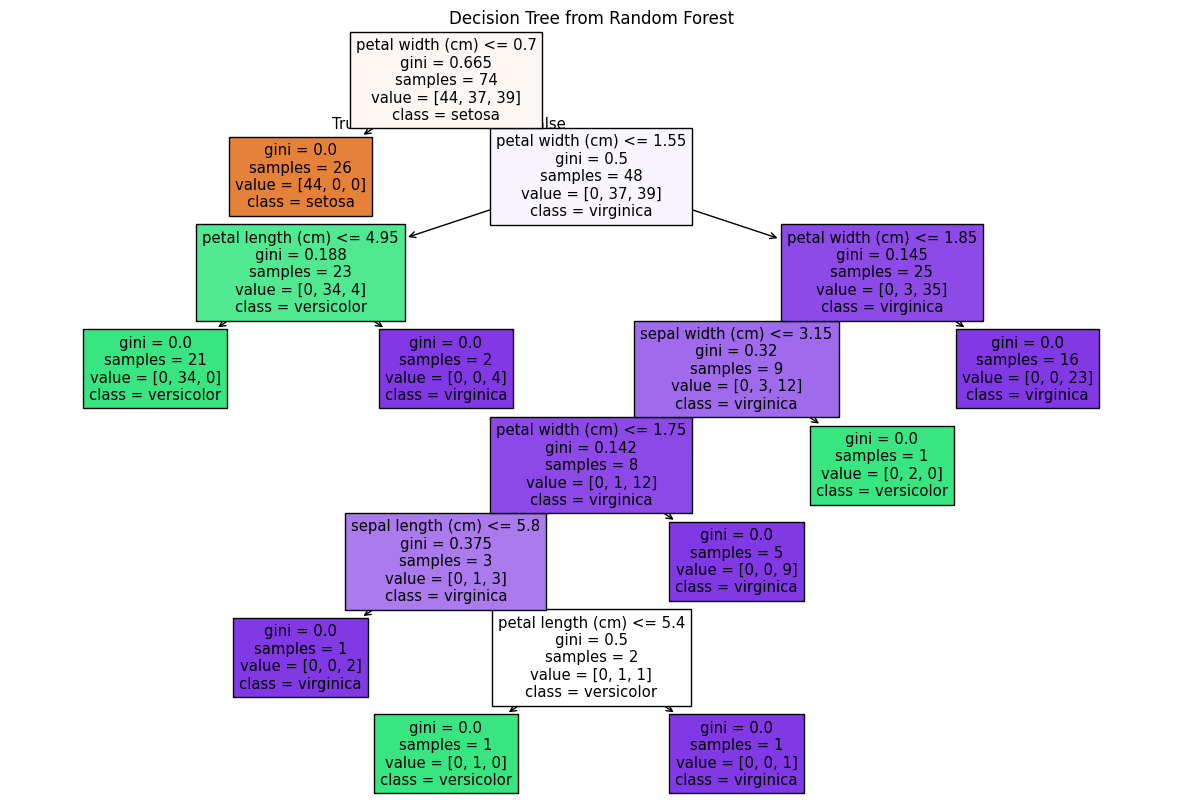

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Select one tree from the forest
tree = rf.estimators_[0]

plt.figure(figsize=(15,10))

plot_tree(
    tree,
    feature_names=df.columns[:-1],
    class_names=['setosa','versicolor','virginica'],
    filled=True
)

plt.title("Decision Tree from Random Forest")

plt.show()


In [ ]:
# Take input from user
print("Enter the flower measurements")

sepal_length = float(input("Sepal Length: "))
sepal_width = float(input("Sepal Width: "))
petal_length = float(input("Petal Length: "))
petal_width = float(input("Petal Width: "))

# Create input array
new_data = [[sepal_length, sepal_width, petal_length, petal_width]]

# Predict using trained model
prediction = rf.predict(new_data)

# Convert numeric class to flower name
flower_name = data.target_names[prediction[0]]

print("Predicted Flower Species:", flower_name)

Enter the flower measurements
Sepal Length: 5.94
Sepal Width: 2.77
Petal Length: 4.26
Petal Width: 1.33
Predicted Flower Species: versicolor


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


**Inference:** Random Forest consists of multiple decision trees built using random subsets of data and features. Each tree makes a prediction independently, and the final output is determined using majority voting. For visualization, one decision tree from the forest can be plotted to understand how the model splits features to classify the data.